In [161]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [162]:
!pip install lightgbm optuna 

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
 

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
)

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
import numpy as np


import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

In [164]:
df = pd.read_csv("data_D.csv")
df

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.770000,...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,0x1c3d4,CUS_0x2346,July,Chanu,32,918-83-4696,Accountant,58892.86_,5106.738333,...,Standard,666.0,29.716761,33 Years and 3 Months,Yes,118.348232,213.8312235074904,High_spent_Small_value_payments,438.49437811272605,Standard
24996,24996,0xa1aa,CUS_0x81e2,May,James Regang,45,662-55-6547,_______,75042.72,6484.560000,...,Standard,417.62,42.662754,17 Years and 7 Months,Yes,105.684175,80.53114128738457,High_spent_Large_value_payments,702.2406836898317,Standard
24997,24997,0x1f36,CUS_0x1d4e,May,McCranke,37,182-25-5092,Journalist,25530.33,2137.527500,...,Standard,761.18,35.252857,31 Years and 9 Months,NM,0.000000,64.22191842939257,!@9#%8,429.53083157060746,Standard
24998,24998,0x24fd8,CUS_0x1ec2,July,Rossr,21,258-93-2064,Scientist,34458.06,3142.505000,...,Bad,4404.79,37.234923,13 Years and 11 Months,NM,119.622458,__10000__,High_spent_Small_value_payments,332.42502256666165,Standard


In [165]:
df = df.drop(columns=["Unnamed: 0", "ID", "Customer_ID", "Name", "SSN"])

Penghapusan dilakukan karena terlalu banyak unique value sehingga tidak akan relevan untuk predicting selanjutnya.

In [166]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,June,32,Doctor,56125.5,4875.125000,8,3,18,2,"Credit-Builder Loan, and Mortgage Loan",...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,March,39,Entrepreneur,62148.0,NaN,9,7,24,5,"Mortgage Loan, Personal Loan, Payday Loan, Per...",...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,February,45,Accountant,88380.16,7471.013333,7,7,19,3,"Student Loan, Home Equity Loan, and Credit-Bui...",...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,June,32,_______,7821.24,468.770000,8,10,29,6,"Mortgage Loan, Personal Loan, Home Equity Loan...",...,Bad,2924.76,34.203026,10 Years and 2 Months,Yes,19.727923,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,June,18,Scientist,107871.9,NaN,3,4,8,3,"Student Loan, Mortgage Loan, and Credit-Builde...",...,Standard,1005.83,27.237916,32 Years and 8 Months,No,227.241789,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21173 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22120 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23256 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24503 non-null  float64
 14  Credit

Dari df.info ini terlihat bahwa ada missing value, contohnya berada di:
1. `Monthly_Inhand_Salary`    
2. `Type_of_Loan`              
3. `Num_of_Delayed_Payment`    
4. `Num_Credit_Inquiries`       
5. `Credit_History_Age`       
6. `Monthly_Balance`          


Di kolom yang seharusnya numerik menjadi object. Ini berarti mungkin terdapat '-', '_' atau yang lain sehingga harus dibersihkan.
1. `Age`
2. `Annual_Income`
3. `Num_of_Loan`
4. `Num_of_Delayed_Payment`
5. `Changed_Credit_Limit`
6. `Outstanding_Debt`


In [168]:
def show_all_unique_object_values(df):
    obj_cols = df.select_dtypes(include=["object"]).columns

    for col in obj_cols:
        uniques = df[col].dropna().unique()
        print(f"\nKolom: {col}")
        print(f"Jumlah unik: {len(uniques)}")
        print("Semua nilai unik:")
        print(uniques)
show_all_unique_object_values(df)


Kolom: Month
Jumlah unik: 8
Semua nilai unik:
['June' 'March' 'February' 'January' 'July' 'April' 'May' 'August']

Kolom: Age
Jumlah unik: 548
Semua nilai unik:
['32' '39' '45' '18' '28' '30' '37' '25' '21' '40' '42' '52_' '22' '43'
 '34' '20' '38' '51' '17' '52' '27' '19' '46' '33' '56' '28_' '26' '53'
 '15' '24_' '36' '31' '29' '24' '14' '23' '54' '47' '49' '41' '23_' '35'
 '16' '44' '1820' '50' '27_' '20_' '48' '44_' '55' '38_' '3651' '5975'
 '36_' '19_' '26_' '30_' '-500' '32_' '7986' '34_' '21_' '55_' '6424'
 '5123' '31_' '2341' '42_' '49_' '6799' '16_' '18_' '8567' '54_' '2175'
 '2037' '37_' '51_' '5995' '7323' '7851' '22_' '2977' '2474_' '46_' '15_'
 '7553' '39_' '43_' '14_' '40_' '359' '1515' '1695' '29_' '2084' '7886'
 '7806' '47_' '1657' '4906' '25_' '41_' '1651' '306' '1220' '2733' '50_'
 '17_' '7459' '53_' '4270' '328' '7776' '940' '774' '5717' '7223' '1787'
 '35_' '45_' '4580' '33_' '3665' '1176' '6777' '5222' '112' '2756' '581'
 '6091' '5018' '2048' '56_' '2209' '8561' '

In [169]:
Not_Numeric_Columns = [
    "Age", 
    "Annual_Income", 
    "Num_of_Loan", 
    "Num_of_Delayed_Payment", 
    "Changed_Credit_Limit", 
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for cols in Not_Numeric_Columns:
    df[cols] = (
        df[cols]
        .astype(str)                         
        .str.replace("_", "", regex=False)   
    )
    
    df[cols] = pd.to_numeric(df[cols], errors='coerce')

Dari bagian atas, dapat dilihat bahwa terdapat value seperti `_100_` di kolom yang seharusnya numerik sehingga saya menghapus dan membuat kolomnya menjadi numerik. 

In [170]:
def show_all_unique_object_values(df):
    obj_cols = df.select_dtypes(include=["object"]).columns

    for col in obj_cols:
        uniques = df[col].dropna().unique()
        print(f"\nKolom: {col}")
        print(f"Jumlah unik: {len(uniques)}")
        print("Semua nilai unik:")
        print(uniques)
show_all_unique_object_values(df)


Kolom: Month
Jumlah unik: 8
Semua nilai unik:
['June' 'March' 'February' 'January' 'July' 'April' 'May' 'August']

Kolom: Occupation
Jumlah unik: 16
Semua nilai unik:
['Doctor' 'Entrepreneur' 'Accountant' '_______' 'Scientist' 'Manager'
 'Architect' 'Journalist' 'Writer' 'Media_Manager' 'Engineer' 'Developer'
 'Mechanic' 'Lawyer' 'Teacher' 'Musician']

Kolom: Type_of_Loan
Jumlah unik: 5690
Semua nilai unik:
['Credit-Builder Loan, and Mortgage Loan'
 'Mortgage Loan, Personal Loan, Payday Loan, Personal Loan, and Home Equity Loan'
 'Student Loan, Home Equity Loan, and Credit-Builder Loan' ...
 'Personal Loan, Credit-Builder Loan, Home Equity Loan, Student Loan, Credit-Builder Loan, and Debt Consolidation Loan'
 'Auto Loan, Debt Consolidation Loan, Student Loan, Personal Loan, Student Loan, Debt Consolidation Loan, Credit-Builder Loan, Student Loan, and Mortgage Loan'
 'Home Equity Loan, Debt Consolidation Loan, Auto Loan, and Student Loan']

Kolom: Credit_Mix
Jumlah unik: 4
Semua nilai 

In [171]:
df["Occupation"] = df["Occupation"].replace("_______", np.nan)
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", "No")
df["Payment_Behaviour"] = df["Payment_Behaviour"].replace("!@9#%8", np.nan)

In [172]:
def show_all_unique_numeric_values(df):
    num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

    for col in num_cols:
        uniques = np.sort(df[col].dropna().unique())
        print(f"\nKolom: {col}")
        print(f"Jumlah unik: {len(uniques)}")
        print("Semua nilai unik:")
        print(uniques)

show_all_unique_numeric_values(df)


Kolom: Age
Jumlah unik: 504
Semua nilai unik:
[-500   14   15   16   17   18   19   20   21   22   23   24   25   26
   27   28   29   30   31   32   33   34   35   36   37   38   39   40
   41   42   43   44   45   46   47   48   49   50   51   52   53   54
   55   56  100  111  112  115  118  123  126  142  189  234  246  252
  262  267  287  292  293  306  316  328  333  335  349  359  365  372
  387  456  488  532  581  623  634  637  651  655  672  678  692  725
  774  813  814  817  819  820  828  831  836  924  925  940  941  946
  956 1022 1033 1051 1062 1094 1102 1176 1188 1206 1220 1232 1265 1294
 1308 1322 1335 1367 1388 1402 1443 1447 1451 1485 1496 1515 1525 1542
 1571 1593 1608 1651 1657 1664 1695 1733 1752 1753 1787 1808 1820 1842
 1868 1923 1947 2027 2037 2048 2076 2084 2090 2097 2106 2109 2113 2117
 2160 2175 2178 2184 2205 2209 2263 2276 2341 2352 2369 2373 2382 2404
 2419 2434 2455 2461 2474 2509 2525 2558 2563 2578 2636 2659 2672 2679
 2713 2721 2733 2749 2756 2799

In [173]:
summary_table = df.select_dtypes(include=['int64', 'float64']).describe().T
summary_table = summary_table[['min', '25%', '50%', '75%', 'max']]
summary_table.columns = ['Min', 'Q1 (25%)', 'Q2 (Median)', 'Q3 (75%)', 'Max']
display(summary_table) 

,Min,Q1 (25%),Q2 (Median),Q3 (75%),Max
Age,-5.000000e+02,25.000000,33.000000,42.000000,8.669000e+03
Annual_Income,7.005930e+03,19536.450000,37404.670000,72413.145000,2.419806e+07
Monthly_Inhand_Salary,3.036454e+02,1625.265833,3080.353333,5927.527500,1.520463e+04
Num_Bank_Accounts,-1.000000e+00,4.000000,6.000000,8.000000,1.794000e+03
Num_Credit_Card,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,1.000000e+00,8.000000,13.000000,20.000000,5.789000e+03
Num_of_Loan,-1.000000e+02,1.000000,3.000000,5.000000,1.485000e+03
Delay_from_due_date,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,-3.000000e+00,9.000000,14.000000,18.000000,4.340000e+03
Changed_Credit_Limit,-6.440000e+00,5.380000,9.380000,14.920000,3.697000e+01


In [174]:
df.loc[(df["Age"] < 0) | (df["Age"] > 100), "Age"] = np.nan
df.loc[(df["Num_Bank_Accounts"] < 0) | (df["Num_Bank_Accounts"] > 10), "Num_Bank_Accounts"] = np.nan
df.loc[(df["Num_of_Loan"] < 0) | (df["Num_of_Loan"] > 10), "Num_of_Loan"] = np.nan
df.loc[(df["Delay_from_due_date"] < 0) | (df["Delay_from_due_date"] > 100), "Delay_from_due_date"] = np.nan
df.loc[(df["Num_of_Delayed_Payment"] < 0) | (df["Num_of_Delayed_Payment"] > 10), "Num_of_Delayed_Payment"] = np.nan
df.loc[(df["Changed_Credit_Limit"] < 0) | (df["Changed_Credit_Limit"] > 100), "Changed_Credit_Limit"] = np.nan
df.loc[(df["Monthly_Balance"] < 0) | (df["Monthly_Balance"] > 10000), "Monthly_Balance"] = np.nan


Dapat dilihat bahwa di beberapa kolom numerik terdapat nilai negatif, sehingga karena tidaklah logis, ssehingga saya menjadikan mereka sebagai missing value. 

In [175]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
cat_null = pd.DataFrame({
    "Null Count": df[cat_cols].isna().sum(),
    "Null Percentage (%)": (df[cat_cols].isna().mean() * 100).round(2)
}).sort_values(by="Null Percentage (%)", ascending=False)
num_null = pd.DataFrame({
    "Null Count": df[num_cols].isna().sum(),
    "Null Percentage (%)": (df[num_cols].isna().mean() * 100).round(2)
}).sort_values(by="Null Percentage (%)", ascending=False)

print("Categorical Columns")
display(cat_null)

print("\nNumerical Columns")
display(num_null)


Categorical Columns


,Null Count,Null Percentage (%)
Credit_Mix,5031,20.12
Type_of_Loan,2880,11.52
Credit_History_Age,2249,9.00
Payment_Behaviour,1894,7.58
Occupation,1735,6.94
Month,0,0.00
Payment_of_Min_Amount,0,0.00
Credit_Score,0,0.00



Numerical Columns


,Null Count,Null Percentage (%)
Num_of_Delayed_Payment,17285,69.14
Monthly_Inhand_Salary,3827,15.31
Amount_invested_monthly,1121,4.48
Num_of_Loan,1046,4.18
Changed_Credit_Limit,911,3.64
Age,690,2.76
Num_Credit_Inquiries,497,1.99
Num_Bank_Accounts,338,1.35
Monthly_Balance,312,1.25
Delay_from_due_date,141,0.56


In [176]:
#Categorical Columns
df["Credit_Mix"] = df["Credit_Mix"].fillna("Unknown")
missing_cat_cols = ["Credit_History_Age", "Payment_Behaviour", "Occupation"]
for col in missing_cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

num_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  float64
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  float64
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  float64
 9   Type_of_Loan              22120 non-null  object 
 10  Delay_from_due_date       25000 non-null  float64
 11  Num_of_Delayed_Payment    25000 non-null  float64
 12  Changed_Credit_Limit      25000 non-null  float64
 13  Num_Credit_Inquiries      25000 non-null  float64
 14  Credit

In [178]:
df = df.drop_duplicates()

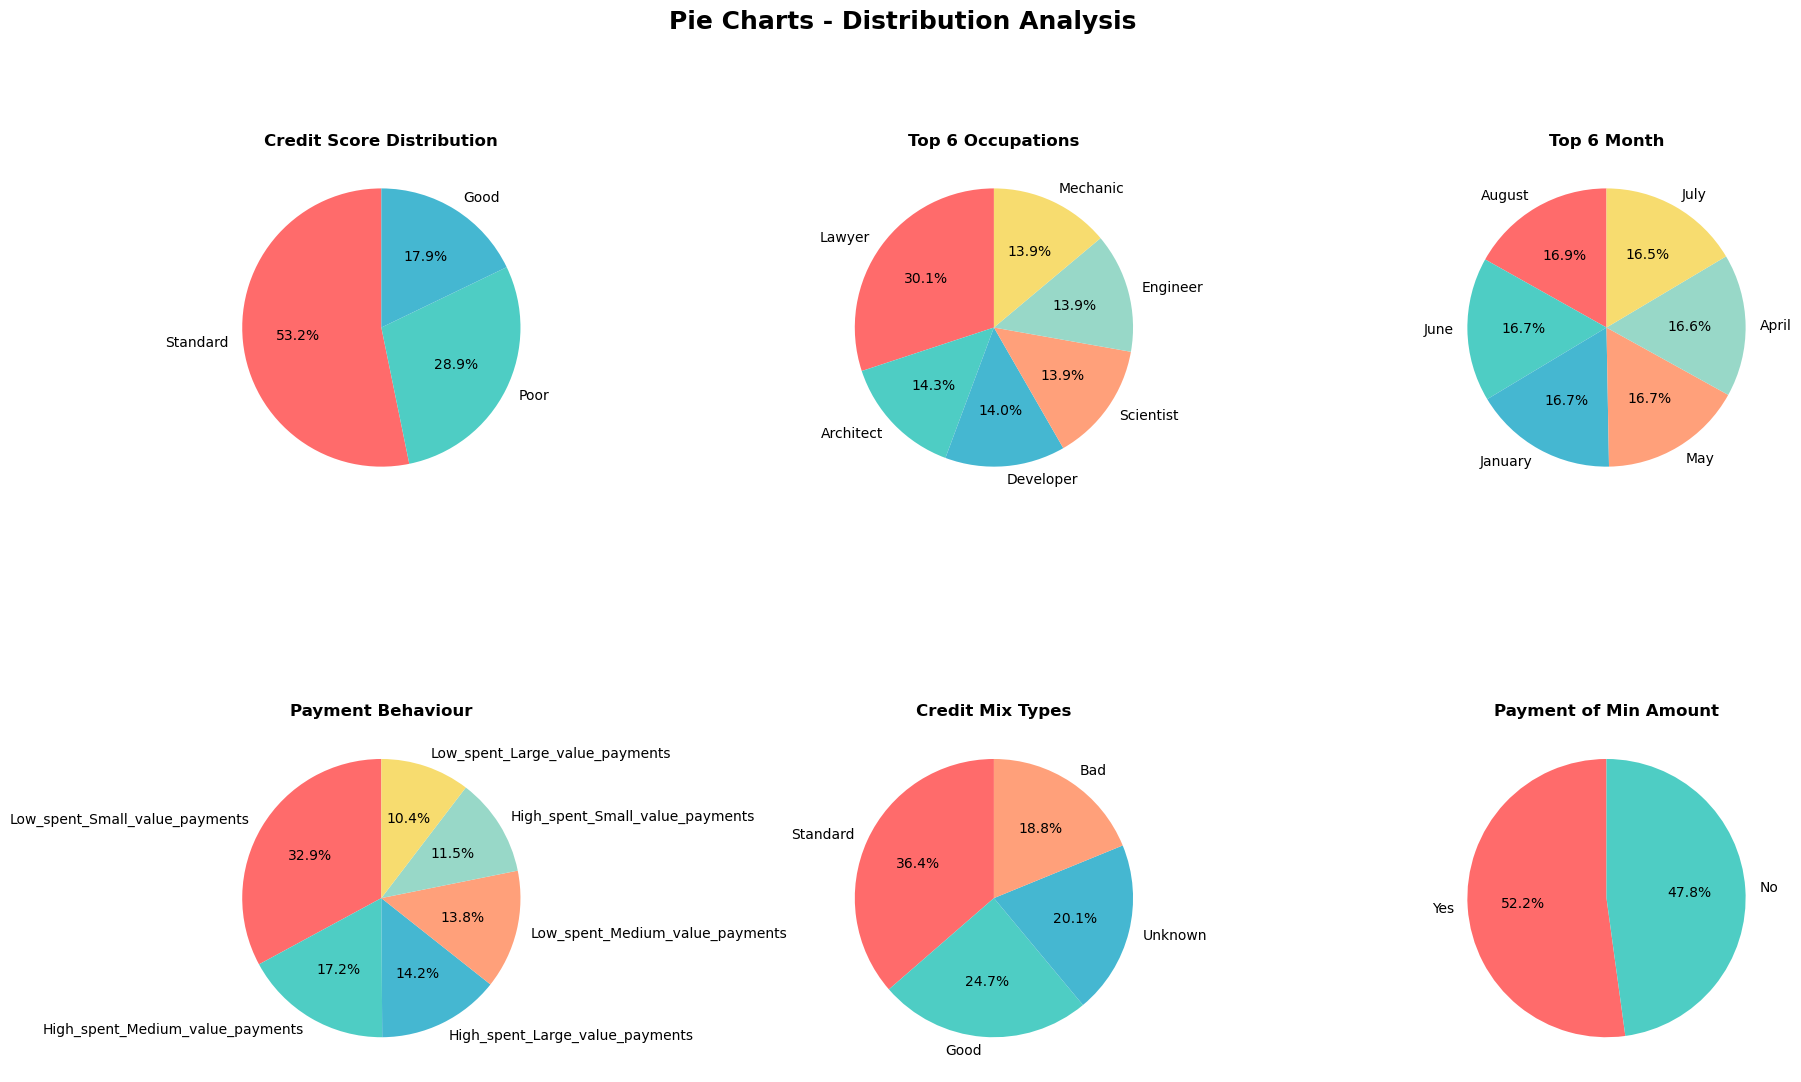

In [179]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Pie Charts - Distribution Analysis', fontsize=18, fontweight='bold')

colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']

# Credit Score Distribution
if 'Credit_Score' in df.columns:
    credit_data = df['Credit_Score'].value_counts()
    axes[0, 0].pie(credit_data.values, labels=credit_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette[:len(credit_data)])
    axes[0, 0].set_title('Credit Score Distribution', fontsize=12, fontweight='bold')

# Occupation Distribution
if 'Occupation' in df.columns:
    occ_data = df['Occupation'].value_counts().head(6)
    axes[0, 1].pie(occ_data.values, labels=occ_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette)
    axes[0, 1].set_title('Top 6 Occupations', fontsize=12, fontweight='bold')

# Month Distribution
if 'Month' in df.columns:
    month_data = df['Month'].value_counts().head(6)
    axes[0, 2].pie(month_data.values, labels=month_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette)
    axes[0, 2].set_title('Top 6 Month', fontsize=12, fontweight='bold')

# Payment Behaviour Distribution
if 'Payment_Behaviour' in df.columns:
    payment_data = df['Payment_Behaviour'].value_counts().head(6)
    axes[1, 0].pie(payment_data.values, labels=payment_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette)
    axes[1, 0].set_title('Payment Behaviour', fontsize=12, fontweight='bold')

# Credit Mix Distribution
if 'Credit_Mix' in df.columns:
    mix_data = df['Credit_Mix'].value_counts()
    axes[1, 1].pie(mix_data.values, labels=mix_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette[:len(mix_data)])
    axes[1, 1].set_title('Credit Mix Types', fontsize=12, fontweight='bold')

# Payment of Min Amount Distribution
if 'Payment_of_Min_Amount' in df.columns:
    min_payment_data = df['Payment_of_Min_Amount'].value_counts()
    axes[1, 2].pie(min_payment_data.values, labels=min_payment_data.index, autopct='%1.1f%%',
                   startangle=90, colors=colors_palette[:len(min_payment_data)])
    axes[1, 2].set_title('Payment of Min Amount', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



* **Credit Score Distribution** is dominated by **Standard (53.2%)**, followed by **Poor (28.9%)**, while **Good (17.9%)** is the smallest segment, showing the customer base is mostly average-to-medium credit quality.

* **Top 6 Occupations** shows a strong concentration in **Lawyer (30.1%)**, while the other occupations (**Engineer, Developer, Media Manager, Accountant, Architect**) are relatively evenly distributed (~13–14% each), indicating one occupation group is highly overrepresented.

* **Top 6 Month Distribution** (January–August) is almost evenly split (~16.6–16.9% each), suggesting **no strong seasonal bias** or major monthly spikes in the dataset for these months.

* **Payment Behaviour** is led by **Low_spent_Small_value_payments (33.2%)**, meaning many customers frequently make small-value payments with lower spending levels.

* The remaining payment behaviour categories are spread across multiple groups (high/low spend and medium/large value), indicating **diverse customer spending patterns** rather than one single dominant behaviour type.

* **Credit Mix Types** are mostly **Standard (36.4%)**, followed by **Good (24.7%)**, **Unknown (20.1%)**, and **Bad (18.8%)**, showing a fairly mixed population with a considerable amount of unclear/uncertain credit mix information.

* **Payment of Minimum Amount** is nearly balanced: **Yes (52.2%)** vs **No (47.8%)**, meaning about half of the customers regularly pay only the minimum due, which could be a signal of **potential repayment stress** for a large segment.

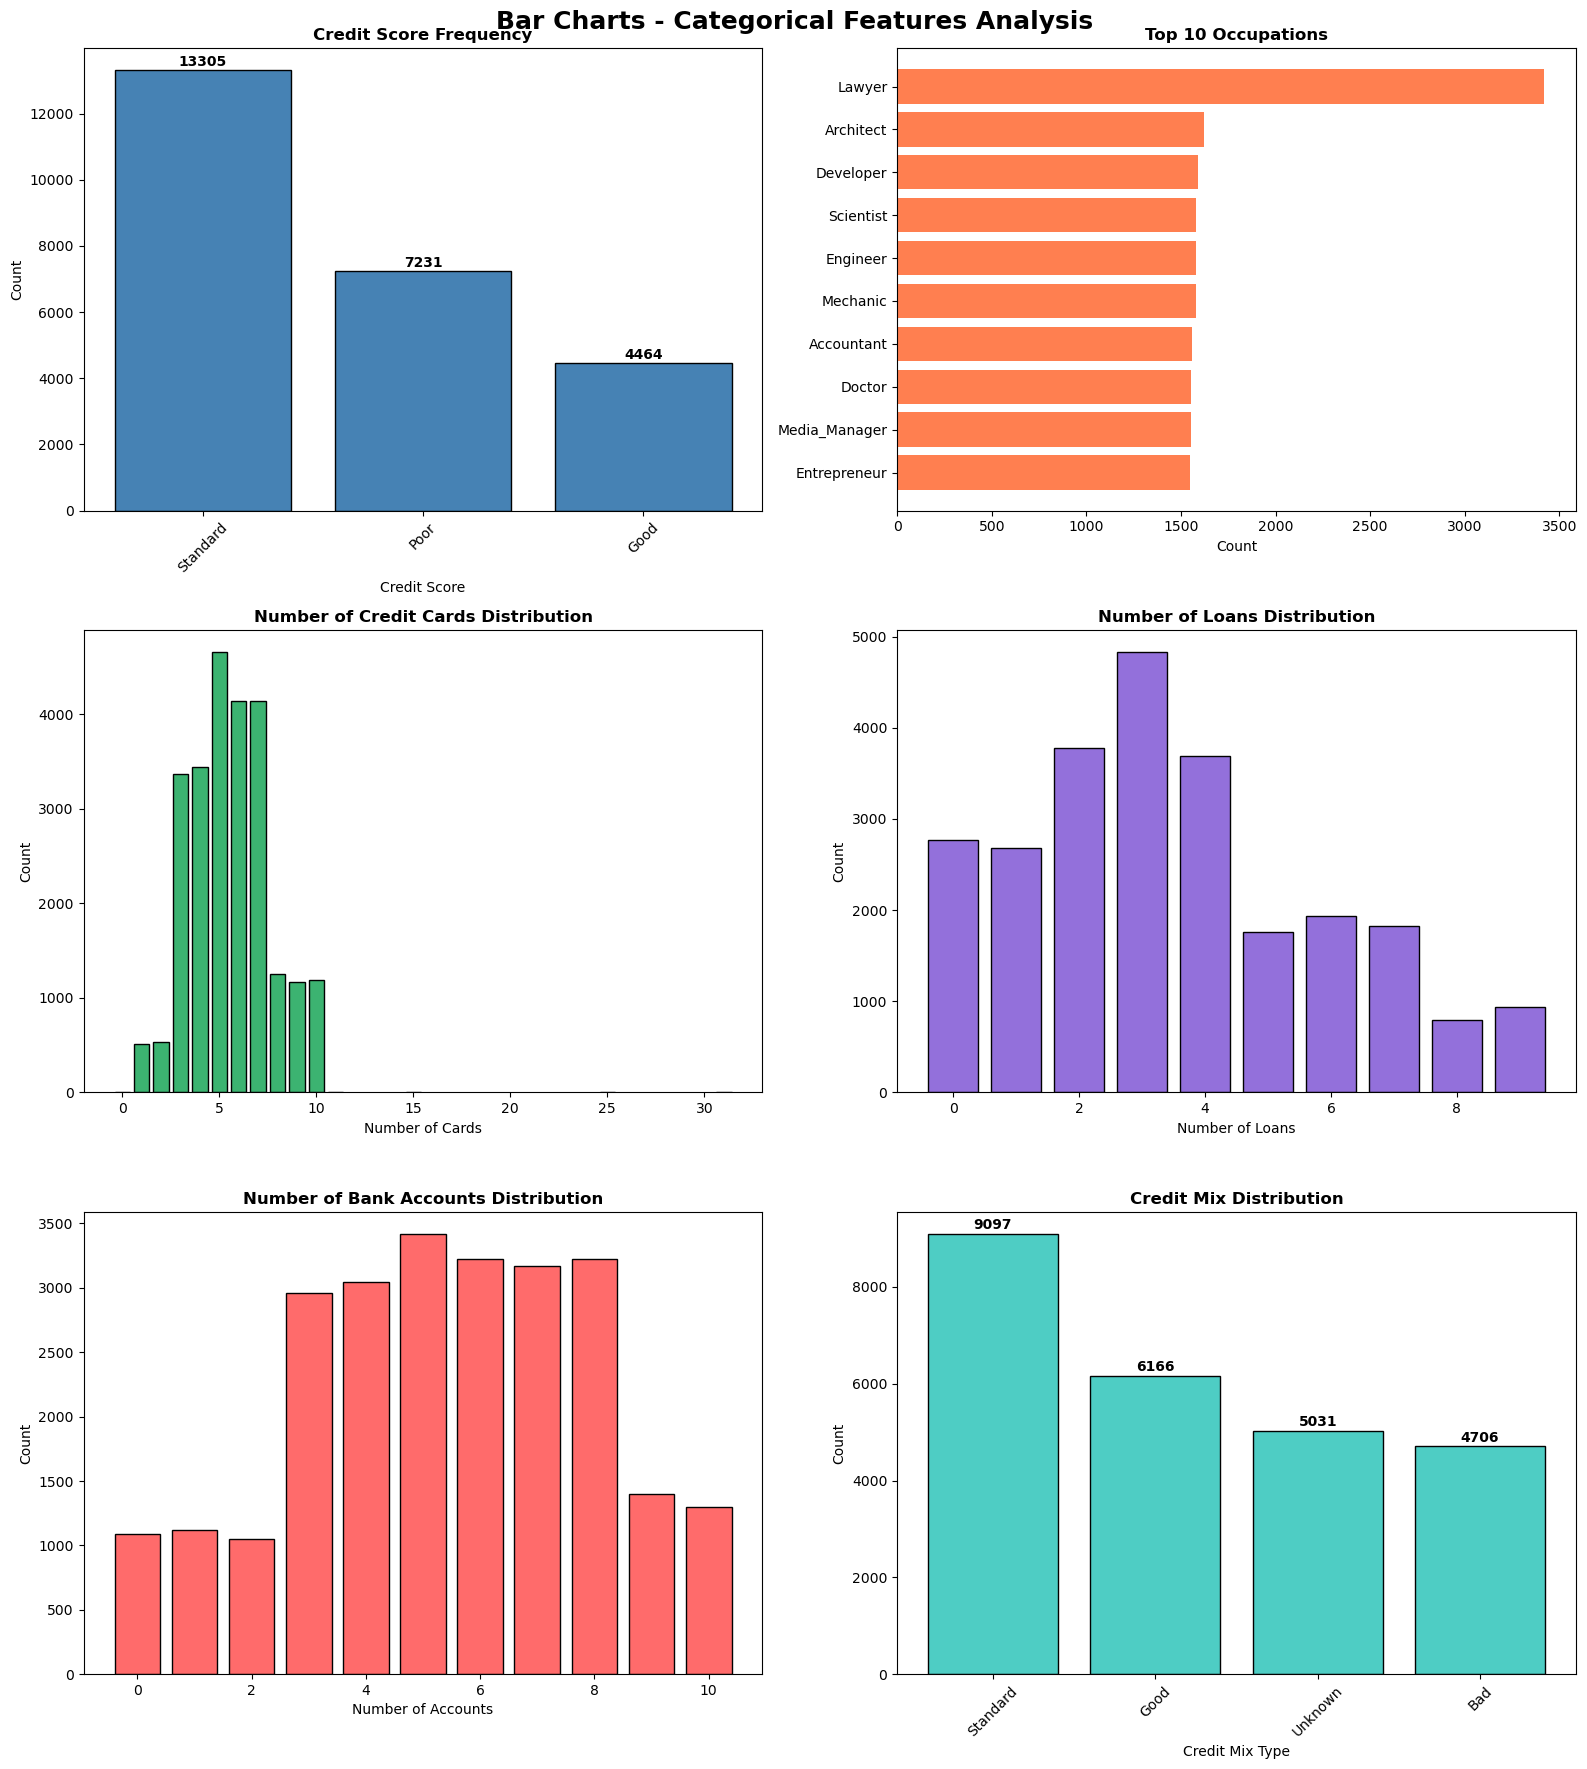

In [180]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Bar Charts - Categorical Features Analysis', fontsize=18, fontweight='bold')

# Credit Score Count
if 'Credit_Score' in df.columns:
    score_counts = df['Credit_Score'].value_counts()
    axes[0, 0].bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Credit Score Frequency', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Credit Score')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(score_counts.values):
        axes[0, 0].text(i, v + max(score_counts.values)*0.01, str(v), ha='center', fontweight='bold')

# Occupation Distribution
if 'Occupation' in df.columns:
    occ_counts = df['Occupation'].value_counts().head(10)
    axes[0, 1].barh(range(len(occ_counts)), occ_counts.values, color='coral')
    axes[0, 1].set_yticks(range(len(occ_counts)))
    axes[0, 1].set_yticklabels(occ_counts.index)
    axes[0, 1].set_title('Top 10 Occupations', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Count')
    axes[0, 1].invert_yaxis()

# Number of Credit Cards Distribution
if 'Num_Credit_Card' in df.columns:
    card_counts = df['Num_Credit_Card'].value_counts().sort_index().head(15)
    axes[1, 0].bar(card_counts.index, card_counts.values, color='mediumseagreen', edgecolor='black')
    axes[1, 0].set_title('Number of Credit Cards Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Number of Cards')
    axes[1, 0].set_ylabel('Count')

# Number of Loans Distribution
if 'Num_of_Loan' in df.columns:
    loan_counts = df['Num_of_Loan'].value_counts().sort_index().head(15)
    axes[1, 1].bar(loan_counts.index, loan_counts.values, color='mediumpurple', edgecolor='black')
    axes[1, 1].set_title('Number of Loans Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Loans')
    axes[1, 1].set_ylabel('Count')

# Number of Bank Accounts Distribution
if 'Num_Bank_Accounts' in df.columns:
    bank_counts = df['Num_Bank_Accounts'].value_counts().sort_index().head(15)
    axes[2, 0].bar(bank_counts.index, bank_counts.values, color='#FF6B6B', edgecolor='black')
    axes[2, 0].set_title('Number of Bank Accounts Distribution', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Number of Accounts')
    axes[2, 0].set_ylabel('Count')

# Credit Mix Distribution
if 'Credit_Mix' in df.columns:
    mix_counts = df['Credit_Mix'].value_counts()
    axes[2, 1].bar(mix_counts.index, mix_counts.values, color='#4ECDC4', edgecolor='black')
    axes[2, 1].set_title('Credit Mix Distribution', fontsize=12, fontweight='bold')
    axes[2, 1].set_xlabel('Credit Mix Type')
    axes[2, 1].set_ylabel('Count')
    axes[2, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(mix_counts.values):
        axes[2, 1].text(i, v + max(mix_counts.values)*0.01, str(v), ha='center', fontweight='bold')

plt.tight_layout()


* The **credit score distribution is imbalanced**, with **Standard** being the dominant category (`~13,305 customers`), followed by **Poor** (`~7,231`), while **Good** is the smallest group (`~4,464`).

* The dataset contains a **large portion of customers with Poor credit scores**, which may indicate a **higher-risk population** and potential challenges for credit-related decision making.

* **Lawyer** is the most common occupation by a large margin, while the other top occupations (Engineer, Developer, Media Manager, Accountant, Architect, Mechanic, Entrepreneur, Teacher, Scientist) have relatively similar frequencies.

* The occupation distribution suggests the dataset may be **professionally skewed** (not evenly representing all job types), which could affect fairness or generalization in modeling.

* The **number of credit cards** is mostly concentrated around **3–7 cards**, with the peak occurring in the mid-range, meaning most customers own a moderate number of cards.

* The **number of loans** shows a decreasing pattern: **2 and 3 loan is the most common**, and the frequency generally drops as the number of loans increases, indicating most customers have **low to moderate borrowing activity**.

* The **number of bank accounts** is concentrated around **4–8 accounts**, suggesting most customers manage multiple financial accounts, but extremely high values are rare.

* The **credit mix distribution** is led by **Standard** (`~9,097`), followed by **Good** (`~6,166`), while **Unknown** (`~5,031`) and **Bad** (`~4,706`) are also substantial segments.


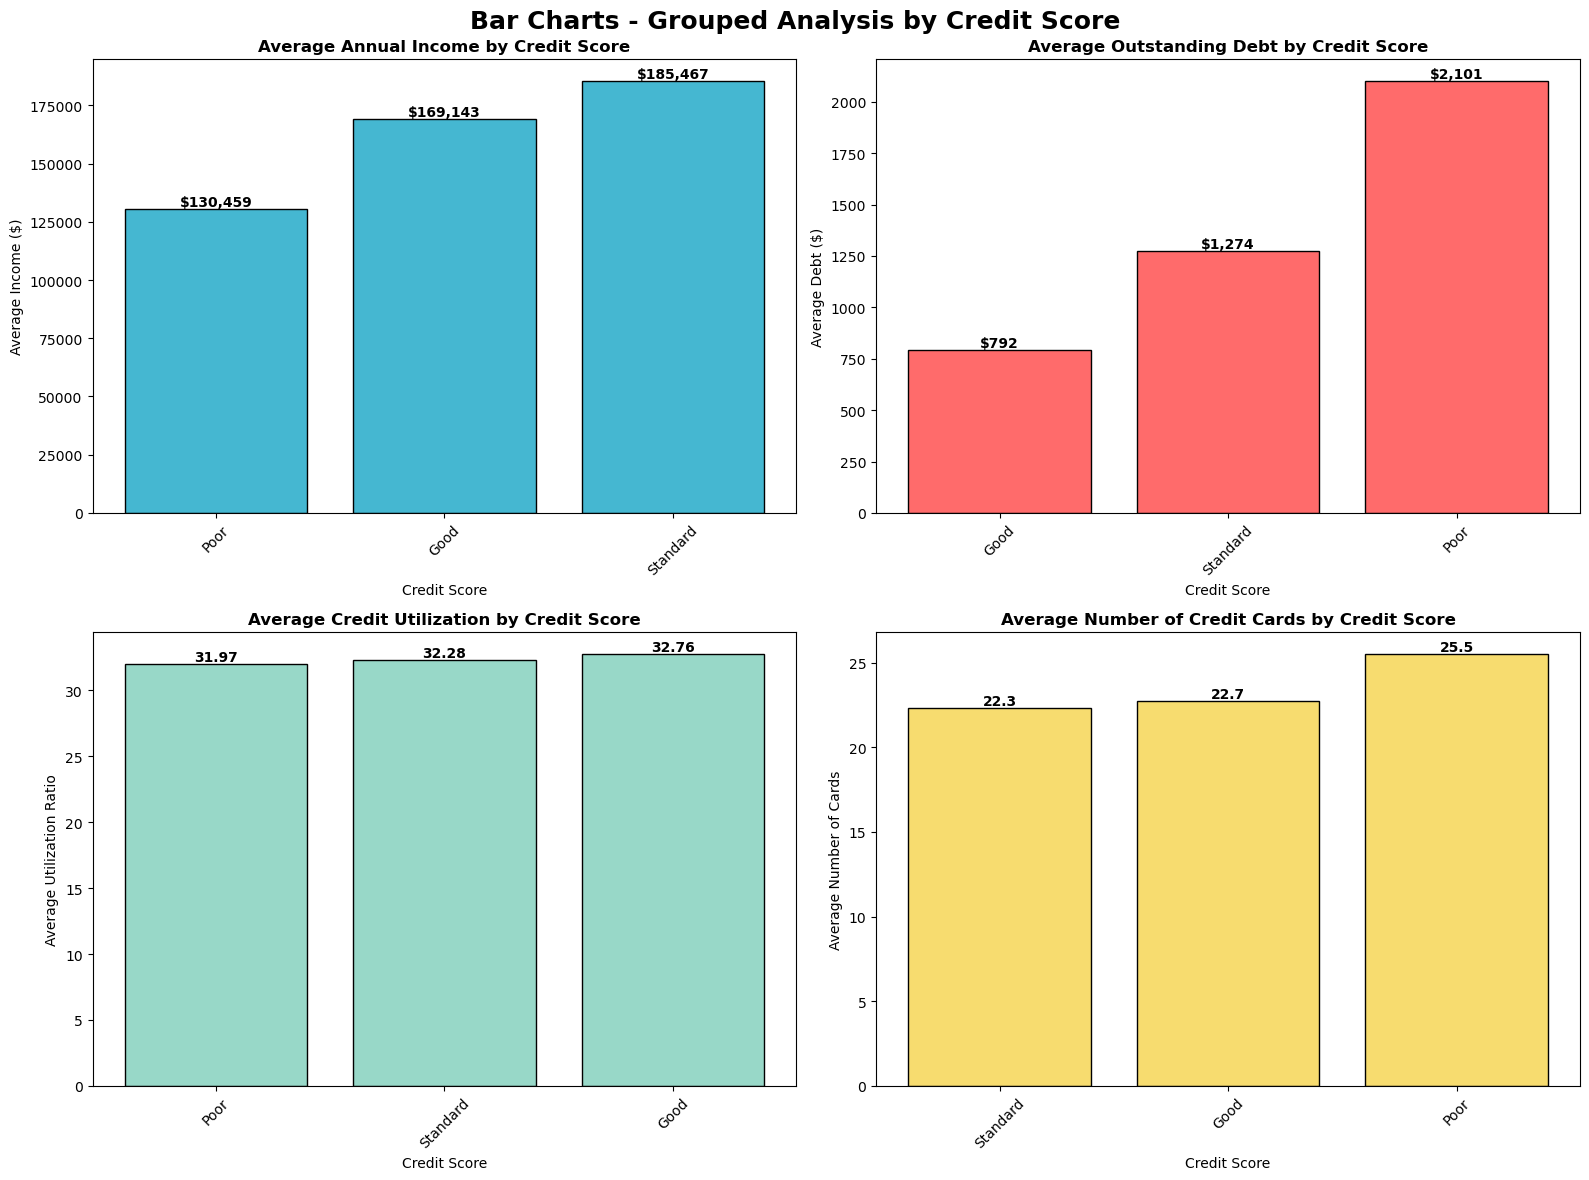

In [181]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bar Charts - Grouped Analysis by Credit Score', fontsize=18, fontweight='bold')

# Average Annual Income by Credit Score
if 'Annual_Income' in df.columns and 'Credit_Score' in df.columns:
    income_by_score = df.groupby('Credit_Score')['Annual_Income'].mean().sort_values()
    axes[0, 0].bar(income_by_score.index, income_by_score.values, color='#45B7D1', edgecolor='black')
    axes[0, 0].set_title('Average Annual Income by Credit Score', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Credit Score')
    axes[0, 0].set_ylabel('Average Income ($)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(income_by_score.values):
        axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Average Outstanding Debt by Credit Score
if 'Outstanding_Debt' in df.columns and 'Credit_Score' in df.columns:
    debt_by_score = df.groupby('Credit_Score')['Outstanding_Debt'].mean().sort_values()
    axes[0, 1].bar(debt_by_score.index, debt_by_score.values, color='#FF6B6B', edgecolor='black')
    axes[0, 1].set_title('Average Outstanding Debt by Credit Score', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Credit Score')
    axes[0, 1].set_ylabel('Average Debt ($)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(debt_by_score.values):
        axes[0, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')

# Average Credit Utilization by Credit Score
if 'Credit_Utilization_Ratio' in df.columns and 'Credit_Score' in df.columns:
    util_by_score = df.groupby('Credit_Score')['Credit_Utilization_Ratio'].mean().sort_values()
    axes[1, 0].bar(util_by_score.index, util_by_score.values, color='#98D8C8', edgecolor='black')
    axes[1, 0].set_title('Average Credit Utilization by Credit Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Credit Score')
    axes[1, 0].set_ylabel('Average Utilization Ratio')
    axes[1, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(util_by_score.values):
        axes[1, 0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Average Number of Credit Cards by Credit Score
if 'Num_Credit_Card' in df.columns and 'Credit_Score' in df.columns:
    cards_by_score = df.groupby('Credit_Score')['Num_Credit_Card'].mean().sort_values()
    axes[1, 1].bar(cards_by_score.index, cards_by_score.values, color='#F7DC6F', edgecolor='black')
    axes[1, 1].set_title('Average Number of Credit Cards by Credit Score', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Credit Score')
    axes[1, 1].set_ylabel('Average Number of Cards')
    axes[1, 1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(cards_by_score.values):
        axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()


* **Average Annual Income** is **lowest for “Poor”** (`~$130,459`) and higher for **“Good”** (`~$169,143`) and **“Standard”** (`~$185,467`), indicating that customers with better credit scores tend to have higher income.

* **Average Outstanding Debt** is **highest for “Poor”** (`~$2,101`), followed by **“Standard”** (`~$1,274`), and **lowest for “Good”** (`~$792`), showing a clear relationship where worse credit scores are associated with higher debt burden.

* **Average Credit Utilization Ratio** is **very similar across all credit score groups** (~**32%**), meaning credit utilization alone may not strongly differentiate credit score categories in this dataset.

* **Average Number of Credit Cards** is **highest for “Poor”** (`~25.5`), followed by **Good** (`~22.7`), and lowest for **Standard** (`~22.3`), suggesting that customers with worse credit scores may hold more credit cards (potentially reflecting higher credit dependency or riskier credit behavior).


In [ ]:
import re
def convert_credit_history_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    years = 0
    months = 0

    if "Years" in x:
        years = int(x.split("Years")[0].strip())
    if "Months" in x:
        months = int(x.split("Months")[0].split()[-1].strip())

    return years * 12 + months

def count_loans(type_str):
    if pd.isna(type_str) or str(type_str).strip() == "":
        return 0

    s = str(type_str).strip()
    s = re.sub(r"\s+and\s+", ",", s)
    items = [x.strip() for x in s.split(",") if x.strip() != ""]
    return len(items)

def perform_feature_engineering(df):
    df = df.copy()

    df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history_age)
    df["Credit_History_Age"] = df["Credit_History_Age"].fillna(df["Credit_History_Age"].median())
    
    epsilon = 1e-5

    df['Savings_Rate'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + epsilon)
    df['Delay_Ratio'] = df['Num_of_Delayed_Payment'] / (df['Num_Bank_Accounts'] + df['Num_Credit_Card'] + epsilon)

    credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
    df['Credit_Mix_Encoded'] = df['Credit_Mix'].map(credit_mix_map).fillna(-1)
    
    payment_min_map = {'No': 0, 'NM': 1, 'Yes': 2}
    df['Payment_Min_Encoded'] = df['Payment_of_Min_Amount'].map(payment_min_map).fillna(-1)

    
    return df


In [ ]:
df_featured = perform_feature_engineering(df)

fitur_baru = [
    'Credit_History_Age', 'Savings_Rate', 'Delay_Ratio', 
    'Credit_Mix_Encoded', 'Payment_Min_Encoded', 'Credit_Score_Encoded'
]

df_numeric = df_featured[fitur_baru].select_dtypes(include=[np.number])

target_col = 'Credit_Score_Encoded'

hasil_analisis = []

for kolom in df_numeric.columns:
    if kolom != target_col:
        df_clean = df_numeric[[kolom, target_col]].dropna()
        
        corr, p_value = spearmanr(df_clean[kolom], df_clean[target_col])
        
        significance = "Significant" if p_value < 0.05 else "Not Significant"
        
        hasil_analisis.append({
            'Feature': kolom,
            'Correlation': corr,
            'P-Value': p_value,
            'Significance': significance
        })

df_korelasi = pd.DataFrame(hasil_analisis)

df_korelasi = df_korelasi.sort_values(by='Correlation', ascending=False).reset_index(drop=True)

print(df_korelasi.to_string())

               Feature  Correlation        P-Value Significance
0  Payment_Min_Encoded     0.189326  1.910297e-200  Significant
1          Delay_Ratio     0.026421   2.940043e-05  Significant
2         Savings_Rate     0.013309   3.535474e-02  Significant
3   Credit_History_Age    -0.043421   6.496118e-12  Significant
4   Credit_Mix_Encoded    -0.128455   1.888154e-92  Significant


In [187]:
target_col = "Credit_Score"

le = LabelEncoder()
df[target_col + "_Encoded"] = le.fit_transform(df[target_col])

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

results = []

for col in numeric_cols:
    if col != target_col + "_Encoded":        
        temp_df = df[[col, target_col + "_Encoded"]].dropna()

        corr, p_value = pearsonr(
            temp_df[col],
            temp_df[target_col + "_Encoded"]
        )

        significance = "Significant" if p_value < 0.05 else "Not Significant"

        results.append({
            "Feature": col,
            "Correlation": corr,
            "P-Value": p_value,
            "Significance": significance
        })

corr_df = pd.DataFrame(results)

corr_df = corr_df.reindex(
    corr_df["Correlation"].abs().sort_values(ascending=False).index
)

corr_df = corr_df.reset_index(drop=True)

print(corr_df)

                     Feature  Correlation        P-Value     Significance
0       Changed_Credit_Limit     0.180153  2.240397e-181      Significant
1          Num_Bank_Accounts     0.170843  4.735609e-163      Significant
2     Num_of_Delayed_Payment     0.154818  6.622343e-134      Significant
3        Delay_from_due_date     0.096776   4.331751e-53      Significant
4      Monthly_Inhand_Salary    -0.071041   2.419428e-29      Significant
5                        Age    -0.068660   1.630774e-27      Significant
6            Monthly_Balance    -0.065975   1.585946e-25      Significant
7                Num_of_Loan     0.061155   3.737435e-22      Significant
8           Outstanding_Debt     0.035760   1.552101e-08      Significant
9   Credit_Utilization_Ratio    -0.021419   7.069542e-04      Significant
10   Amount_invested_monthly    -0.010778   8.836991e-02  Not Significant
11             Interest_Rate    -0.009678   1.259548e-01  Not Significant
12             Annual_Income     0.009

In [189]:
df = df.drop(columns=['Total_EMI_per_month', 'Num_Credit_Inquiries'])

In [ ]:
target_col = "Credit_Score"

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

categorical_cols = [col for col in categorical_cols if col != target_col]

results = []

for col in categorical_cols:
    
    temp_df = df[[col, target_col]].dropna()

    contingency_table = pd.crosstab(temp_df[col], temp_df[target_col])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1

    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = 0

    # Signifikansi
    significance = "Significant" if p_value < 0.05 else "Not Significant"

    results.append({
        "Categorical_Feature": col,
        "Chi2": chi2,
        "P_Value": p_value,
        "Cramers_V": cramers_v,
        "Significance": significance
    })

result_df = pd.DataFrame(results)
result_df = result_df.sort_values(
    by="Cramers_V",
    ascending=False
).reset_index(drop=True)

print("\nHasil Korelasi Kategorik VS Credit Score\n")
print(result_df)


--- HASIL KORELASI KOLOM KATEGORIK VS CREDIT_SCORE ---

     Categorical_Feature          Chi2       P_Value  Cramers_V Significance
0           Type_of_Loan  19708.366894  0.000000e+00   0.667448  Significant
1  Payment_of_Min_Amount   4083.621680  0.000000e+00   0.404159  Significant
2             Credit_Mix   7682.468238  0.000000e+00   0.391981  Significant
3     Credit_History_Age   4711.123938  0.000000e+00   0.306957  Significant
4      Payment_Behaviour    301.911362  6.131280e-59   0.077706  Significant
5                  Month     68.072394  4.302797e-09   0.036898  Significant
6             Occupation     63.917914  1.256735e-04   0.035754  Significant


In [191]:
df = perform_feature_engineering(df)

target_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
y = df['Credit_Score'].map(target_mapping)

X = df.drop(columns=['Credit_Score'])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [195]:
num_cols = [
    'Monthly_Inhand_Salary', 'Delay_from_due_date', 'Changed_Credit_Limit',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Monthly_Balance',
    'Amount_invested_monthly', 'Num_Bank_Accounts', 'Interest_Rate',
    'Annual_Income', 'Num_of_Delayed_Payment', 'Age', 'Num_Credit_Card', 'Num_of_Loan', 'Savings_Rate', 'Delay_Ratio',
    'Credit_Mix_Encoded', 'Payment_Min_Encoded',
]

ordinal_cols = ['Payment_Behaviour']
cat_cols = ['Month', 'Occupation', 'Payment_of_Min_Amount', 'Credit_Mix']
payment_order = [
    'Low_spent_Small_value_payments', 'Low_spent_Medium_value_payments', 'Low_spent_Large_value_payments',
    'High_spent_Small_value_payments', 'High_spent_Medium_value_payments', 'High_spent_Large_value_payments'
]

In [196]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), num_cols),
        ("ord", OrdinalEncoder(categories=[payment_order]), ordinal_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [200]:
semua_kolom_pipeline = num_cols + ordinal_cols + cat_cols
kolom_hilang = [col for col in semua_kolom_pipeline if col not in X_train.columns]
print("Kolom yang bikin error (tidak ditemukan di X_train):", kolom_hilang)

Kolom yang bikin error (tidak ditemukan di X_train): []


In [ ]:
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Shape X_train asli :", X_train.shape)
print("Shape X_test asli  :", X_test.shape)

print("Shape X_train setelah preprocessing :", X_train_transformed.shape)
print("Shape X_test setelah preprocessing  :", X_test_transformed.shape)

Shape X_train asli : (20000, 26)
Shape X_test asli  : (5000, 26)
Shape X_train setelah preprocessing : (20000, 49)
Shape X_test setelah preprocessing  : (5000, 49)


In [202]:
feature_names = preprocessor.get_feature_names_out()

print("Jumlah fitur:", len(feature_names))

for i, feature in enumerate(feature_names):
    print(i, feature)

Jumlah fitur: 49
0 num__Monthly_Inhand_Salary
1 num__Delay_from_due_date
2 num__Changed_Credit_Limit
3 num__Outstanding_Debt
4 num__Credit_Utilization_Ratio
5 num__Credit_History_Age
6 num__Monthly_Balance
7 num__Amount_invested_monthly
8 num__Num_Bank_Accounts
9 num__Interest_Rate
10 num__Annual_Income
11 num__Num_of_Delayed_Payment
12 num__Age
13 num__Num_Credit_Card
14 num__Num_of_Loan
15 num__Savings_Rate
16 num__Delay_Ratio
17 num__Credit_Mix_Encoded
18 num__Payment_Min_Encoded
19 ord__Payment_Behaviour
20 cat__Month_April
21 cat__Month_August
22 cat__Month_February
23 cat__Month_January
24 cat__Month_July
25 cat__Month_June
26 cat__Month_March
27 cat__Month_May
28 cat__Occupation_Accountant
29 cat__Occupation_Architect
30 cat__Occupation_Developer
31 cat__Occupation_Doctor
32 cat__Occupation_Engineer
33 cat__Occupation_Entrepreneur
34 cat__Occupation_Journalist
35 cat__Occupation_Lawyer
36 cat__Occupation_Manager
37 cat__Occupation_Mechanic
38 cat__Occupation_Media_Manager
39 cat

In [203]:
def objective(trial):
    model_type = trial.suggest_categorical(
        "model_type", 
        ["xgboost", "random_forest", "lightgbm"]
    )

    smote_k_neighbors = trial.suggest_int("smote_k_neighbors", 3, 7)
    smote = SMOTE(k_neighbors=smote_k_neighbors, random_state=42)

    if model_type == "xgboost":
        params = {
            "n_estimators": trial.suggest_int("xgb_n_estimators", 100, 500),
            "max_depth": trial.suggest_int("xgb_max_depth", 3, 12),
            "learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.3),
            "subsample": trial.suggest_float("xgb_subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("xgb_gamma", 0, 5),
            "min_child_weight": trial.suggest_int("xgb_min_child_weight", 1, 10),
            "objective": "multi:softprob",
            "eval_metric": "mlogloss",
            "random_state": 42,
            "n_jobs": -1
        }
        model = XGBClassifier(**params)
        
    elif model_type == "random_forest":
        params = {
            "n_estimators": trial.suggest_int("rf_n_estimators", 100, 500),
            "max_depth": trial.suggest_int("rf_max_depth", 5, 20),
            "min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("rf_min_samples_leaf", 1, 10),
            "criterion": trial.suggest_categorical("rf_criterion", ["gini", "entropy"]),
            "max_features": trial.suggest_categorical("rf_max_features", ["sqrt", "log2", None]),
            "class_weight": trial.suggest_categorical("rf_class_weight", [None, "balanced"]),
            "random_state": 42,
            "n_jobs": -1
        }
        model = RandomForestClassifier(**params)
        
    elif model_type == "lightgbm":
        params = {
            "n_estimators": trial.suggest_int("lgb_n_estimators", 100, 500),
            "max_depth": trial.suggest_int("lgb_max_depth", 3, 12),
            "learning_rate": trial.suggest_float("lgb_learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("lgb_num_leaves", 20, 150),
            "subsample": trial.suggest_float("lgb_subsample", 0.5, 1.0),
            "objective": "multiclass",
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1
        }
        model = LGBMClassifier(**params)
        

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline, X_train, y_train, cv=5, scoring="f1_weighted", n_jobs=-1
    ).mean()

    return score

In [ ]:
import optuna
from optuna.storages import InMemoryStorage

early_stopping_callback = optuna.study.MaxTrialsCallback(
    n_trials=50
)  

from optuna.trial import TrialState


class EarlyStoppingCallback:

    def __init__(self, patience: int):
        self.patience = patience
        self._best_score = None
        self._stagnant_trials = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        if study.direction == optuna.study.StudyDirection.MAXIMIZE:
            current_score = trial.value
            if current_score is None:
                return

            if self._best_score is None or current_score > self._best_score:
                self._best_score = current_score
                self._stagnant_trials = 0
            else:
                self._stagnant_trials += 1

        if self._stagnant_trials >= self.patience:
            print(
                f"\n[Early Stopping] Dihentikan lebih awal! Skor tidak membaik selama {self.patience} trial terakhir."
            )
            study.stop()


study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=50,
    callbacks=[EarlyStoppingCallback(patience=15)],
    n_jobs=1,  
)

print("\nHasil Optimasi:")
print(f"Skor F1-Weighted Terbaik: {study.best_value:.4f}")
print("Parameter Terbaik:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-06-08 21:50:27,503] A new study created in memory with name: no-name-0d3aa17b-a8a0-4e4b-93ca-cbfcf13bf965
[I 2026-06-08 21:50:38,083] Trial 0 finished with value: 0.6974256877483805 and parameters: {'model_type': 'xgboost', 'smote_k_neighbors': 5, 'xgb_n_estimators': 117, 'xgb_max_depth': 7, 'xgb_learning_rate': 0.15486230043290644, 'xgb_subsample': 0.7428984833463962, 'xgb_colsample_bytree': 0.8050257480355245, 'xgb_gamma': 3.6968638620427856, 'xgb_min_child_weight': 2}. Best is trial 0 with value: 0.6974256877483805.
[I 2026-06-08 21:50:49,619] Trial 1 finished with value: 0.691826495629634 and parameters: {'model_type': 'xgboost', 'smote_k_neighbors': 3, 'xgb_n_estimators': 239, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.042802636220334755, 'xgb_subsample': 0.818886660262794, 'xgb_colsample_bytree': 0.9925739930196786, 'xgb_gamma': 4.7628236916869255, 'xgb_min_child_weight': 3}. Best is trial 0 with value: 0.6974256877483805.
[I 2026-06-08 21:51:01,769] Trial 2 finished with


[Early Stopping] Dihentikan lebih awal! Skor tidak membaik selama 15 trial terakhir.

=== HASIL OPTIMASI ===
Skor F1-Weighted Terbaik: 0.7224
Parameter Terbaik:
  - model_type: lightgbm
  - smote_k_neighbors: 5
  - lgb_n_estimators: 412
  - lgb_max_depth: 11
  - lgb_learning_rate: 0.23567669882865788
  - lgb_num_leaves: 150
  - lgb_subsample: 0.9411394234355887


In [212]:
print(le.classes_)

['Good' 'Poor' 'Standard']


Model terbaik yang terpilih: lightgbm
Melatih ulang model terbaik pada seluruh data training...

Classification Report:
              precision    recall  f1-score   support

        Poor       0.73      0.74      0.73      1446
    Standard       0.76      0.77      0.76      2661
        Good       0.65      0.61      0.63       893

    accuracy                           0.73      5000
   macro avg       0.71      0.71      0.71      5000
weighted avg       0.73      0.73      0.73      5000

Confusion Matrix


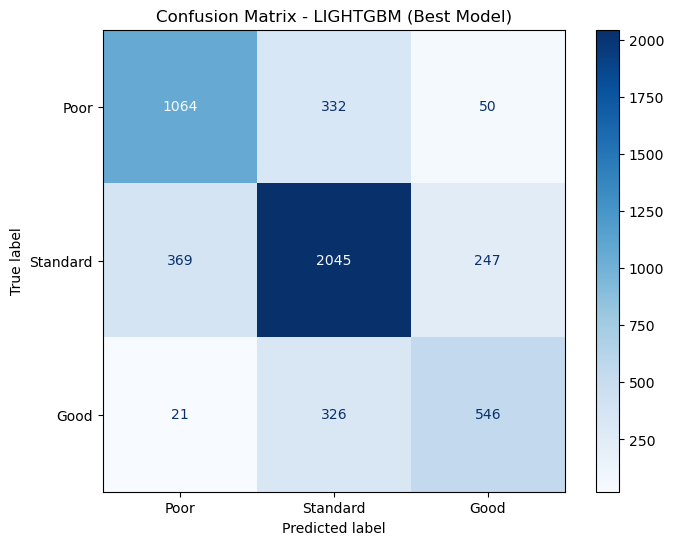

In [ ]:
best_model_type = study.best_params["model_type"]
print(f"Model terbaik yang terpilih: {best_model_type}")
best_smote_k = study.best_params["smote_k_neighbors"]
best_smote = SMOTE(k_neighbors=best_smote_k, random_state=42)

if best_model_type == "xgboost":
    best_params = {
        "n_estimators": study.best_params["xgb_n_estimators"],
        "max_depth": study.best_params["xgb_max_depth"],
        "learning_rate": study.best_params["xgb_learning_rate"],
        "subsample": study.best_params["xgb_subsample"],
        "colsample_bytree": study.best_params["xgb_colsample_bytree"],
        "gamma": study.best_params["xgb_gamma"],
        "min_child_weight": study.best_params["xgb_min_child_weight"],
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "random_state": 42,
        "n_jobs": -1
    }
    best_model = XGBClassifier(**best_params)

elif best_model_type == "random_forest":
    best_params = {
        "n_estimators": study.best_params["rf_n_estimators"],
        "max_depth": study.best_params["rf_max_depth"],
        "min_samples_split": study.best_params["rf_min_samples_split"],
        "min_samples_leaf": study.best_params["rf_min_samples_leaf"],
        "criterion": study.best_params["rf_criterion"],
        "max_features": study.best_params["rf_max_features"],
        "class_weight": study.best_params["rf_class_weight"],
        "random_state": 42,
        "n_jobs": -1
    }
    best_model = RandomForestClassifier(**best_params)

elif best_model_type == "lightgbm":
    best_params = {
        "n_estimators": study.best_params["lgb_n_estimators"],
        "max_depth": study.best_params["lgb_max_depth"],
        "learning_rate": study.best_params["lgb_learning_rate"],
        "num_leaves": study.best_params["lgb_num_leaves"],
        "subsample": study.best_params["lgb_subsample"],
        "objective": "multiclass",
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }
    best_model = LGBMClassifier(**best_params)

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", best_smote),
    ("model", best_model)
])

print("Melatih ulang model terbaik pada seluruh data training...")
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
classes = ['Poor', 'Standard', 'Good']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))

print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title(f"Confusion Matrix - {best_model_type.upper()} (Best Model)")
plt.grid(False) 
plt.show()